# BrushCue Example: Grunge Filter

<a href="https://colab.research.google.com/github/ditotechnologies/brushcue/blob/main/examples/grunge_filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

You can use this tool online at https://www.brushcue.com/tools/grunge-filter

In [ ]:
!pip install brushcue

[wgpu] using backend Vulkan — adapter 'NVIDIA GeForce RTX 5070' (DiscreteGpu), driver 'NVIDIA'


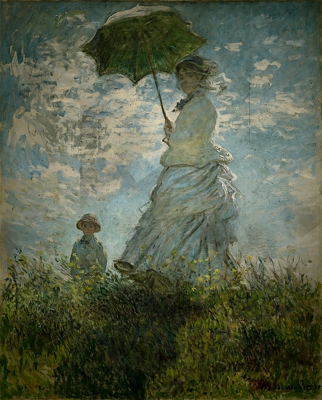

In [1]:
import io
from PIL import Image

import brushcue as bc

input_image = bc.Composition.monet_women_with_parasol()
bounds = input_image.bounds()
wear = bc.Composition.freeform_shader(
    "let uv = (canvas_position - origin) / size;\nlet aspect = size.x / size.y;\nlet p = uv * vec2<f32>(aspect, 1.0);\nlet rotated = vec2<f32>(p.x * 0.8 - p.y * 0.6, p.x * 0.6 + p.y * 0.8);\nlet blotch = vnoise(p * 5.0 + seed) * 0.6 + vnoise(rotated * 14.0 + seed * 2.0) * 0.4;\nlet density = 1.0 - 0.22 * smoothstep(0.45, 0.9, blotch);\nlet column = floor(uv.x * 900.0);\nlet scratch_seed = hash(vec2<f32>(column, seed));\nlet scratch_run = smoothstep(0.55, 0.75, vnoise(vec2<f32>(column * 0.37, uv.y * 7.0 + seed)));\nlet scratch = step(0.9965, scratch_seed) * scratch_run;\nlet cells = uv * vec2<f32>(220.0 * aspect, 220.0);\nlet cell = floor(cells);\nlet speck_seed = hash(cell + seed);\nlet speck_center = vec2<f32>(hash(cell + 7.1), hash(cell + 3.3));\nlet speck_radius = 0.15 + 0.3 * hash(cell + 1.9);\nlet speck = step(0.996, speck_seed) * (1.0 - smoothstep(speck_radius * 0.6, speck_radius, length(fract(cells) - speck_center)));\nlet shade = density * (1.0 - 0.35 * scratch) * (1.0 - 0.6 * speck);\nreturn vec4<f32>(shade, shade, shade * 0.97, 1.0);",
    "fn hash(p: vec2<f32>) -> f32 {\n  return fract(sin(dot(p, vec2<f32>(127.1, 311.7))) * 43758.5453);\n}\nfn vnoise(p: vec2<f32>) -> f32 {\n  let i = floor(p);\n  let f = fract(p);\n  let u = f * f * (3.0 - 2.0 * f);\n  let a = hash(i);\n  let b = hash(i + vec2<f32>(1.0, 0.0));\n  let c = hash(i + vec2<f32>(0.0, 1.0));\n  let d = hash(i + vec2<f32>(1.0, 1.0));\n  return mix(mix(a, b, u.x), mix(c, d, u.x), u.y);\n}",
    bounds,
    bc.ColorRepresentation.srgb(),
    bc.Dictionary.create()
    .add("seed", 11.0)
    .add("origin", bc.Vector2f.from_components(bounds.min_x(), bounds.min_y()))
    .add("size", bc.Vector2f.from_components(bounds.width(), bounds.height())),
)
strength = 1.0
dingy = input_image.saturation_adjust(
    (1.0 - (0.4 * strength))
).color_transformer_shader(
    "var l = input.x;\nlet mid = exp(-pow((l - 0.5) / 0.25, 2.0));\nlet hi = smoothstep(0.72, 1.0, l);\nlet s_curve = l * l * (3.0 - 2.0 * l);\nl = mix(l, s_curve, 0.65 * amount);\nl = max(l - 0.035 * amount, 0.0) / (1.0 - 0.035 * amount);\nl = l - 0.08 * hi * hi * amount;\nlet a = input.y - 0.016 * mid * amount;\nlet b = input.z + (0.03 * mid + 0.02 * hi) * amount;\nreturn vec4<f32>(l, a, b, input.w);",
    "",
    bc.ColorRepresentation.oklab_a(),
    bc.ColorRepresentation.oklab_a(),
    bc.Dictionary.create().add("amount", strength),
)
gritty = dingy.sharpen(2.0, (1.1 * strength)).film_grain(
    (2.6 * strength), 150.0, 0.15, 51.0, 0.55, 300.0, 0.4
)
worn = wear.opacity_scales(strength).blend_multiply(gritty, bc.Transform2.identity())
burned = worn.spacial_effect_shader(
    "let col = sample(position);\nlet uv = (position - origin) / size;\nlet d = (uv - vec2<f32>(0.54, 0.46)) * vec2<f32>(1.0, 1.15);\nlet burn = exp(-dot(d, d) * 2.6);\nlet l = col.x * mix(1.0, 0.5 + 0.5 * burn, amount);\nreturn vec4<f32>(l, col.y, col.z + 0.008 * (1.0 - burn) * amount, col.w);",
    "",
    0.0,
    bc.Dictionary.create()
    .add("amount", strength)
    .add("origin", bc.Vector2f.from_components(bounds.min_x(), bounds.min_y()))
    .add("size", bc.Vector2f.from_components(bounds.width(), bounds.height())),
    bc.ColorRepresentation.oklab_a(),
)
graph = burned.crop(bounds)

ctx = bc.Context()
composition = graph.execute(ctx)
data_bytes = composition.to_image_bytes(ctx)
img = Image.open(io.BytesIO(data_bytes))
img.thumbnail((400, 400))  # Remove this line for full resolution
img
